Classify the email using the binary classification method. Email Spam detection has two states: a)
Normal State – Not Spam, b) Abnormal State – Spam. 

Use Support Vector Machine for classification. Analyze their performance.


Dataset link: The emails.csv dataset on the Kaggle
https://www.kaggle.com/datasets/balaka18/email-spam-classification-dataset-csv

In [1]:
#Step1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

In [2]:
#Step2: Load the dataset 
df = pd.read_csv("D:/KAUSTUBH/LP3 Final/emails.csv")
print(df.head())

  Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   
2   Email 3    0   0    1    0    0   0    8    0    0  ...         0    0   
3   Email 4    0   5   22    0    5   1   51    2   10  ...         0    0   
4   Email 5    7   6   17    1    5   2   57    0    9  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  
2       0    0               0         0         0   0    0           0  
3       0    0               0         0         0   0    0           0  
4       0    0               0         0         0   1    0           0  

[5 rows x 3002 columns]


In [3]:
#Step 3: Data Preprocessing 
#Drop the 'Email' column
df = df.drop(columns=['Email'], errors='ignore')

# Set up features and target variable
X = df.drop(columns=['Prediction'])
y = df['Prediction']

# Convert feature data to numeric, handling any unexpected non-numeric values
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
#Step 4: Train the Support Vector Machine Model

# Initialize and train the SVM model
svm = SVC(kernel='linear', C=1.0)
svm.fit(X_train, y_train)

SVC(kernel='linear')

In [5]:
#Step 5: Predict and evaluate performance
y_pred = svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9568298969072165
Confusion Matrix:
 [[1062   35]
 [  32  423]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97      1097
           1       0.92      0.93      0.93       455

    accuracy                           0.96      1552
   macro avg       0.95      0.95      0.95      1552
weighted avg       0.96      0.96      0.96      1552



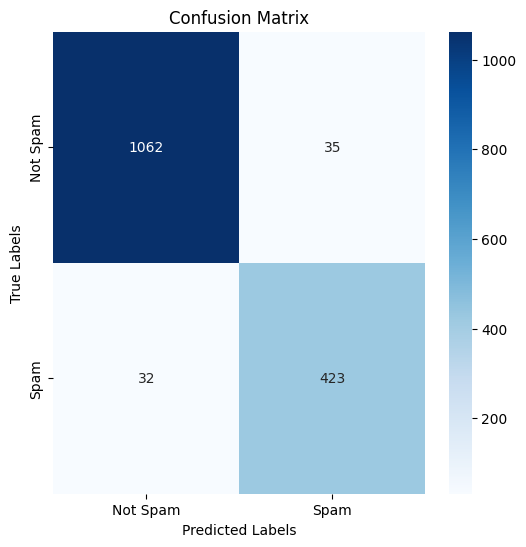

True Negatives: 1062
False Positives: 35
False Negatives: 32
True Positives: 423


In [6]:
#Confusion Matrix 
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# Extract values from the confusion matrix
tn, fp, fn, tp = conf_matrix.ravel()

print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

0.9814739499333847


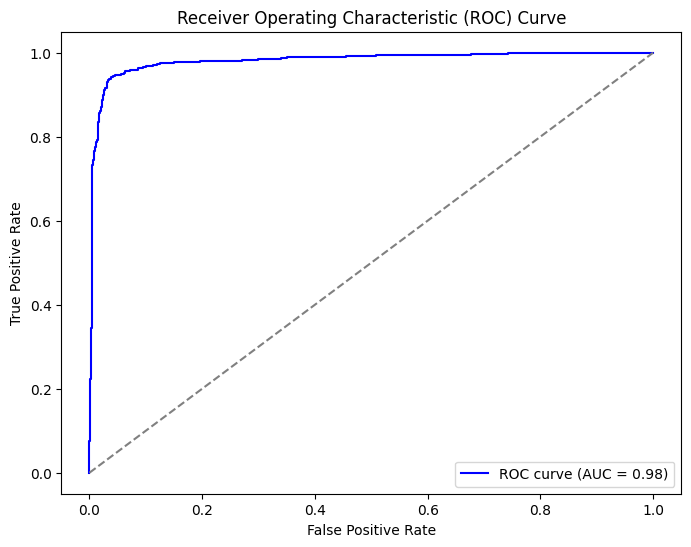

In [7]:
# ROC Curve
y_pred_prob = svm.decision_function(X_test)  # Get decision function scores for ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
print(roc_auc)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()


### 1. **What is an ROC Curve and AUC?**

#### **ROC Curve (Receiver Operating Characteristic Curve)**:
The **ROC curve** is a graphical representation that shows the performance of a **binary classification model** at all classification thresholds. It plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)**, where:

- **True Positive Rate (TPR)** is the same as **Recall**. It is the proportion of actual positive cases correctly identified.
  
  $$
  \text{TPR} = \frac{TP}{TP + FN}
  $$

- **False Positive Rate (FPR)** is the proportion of actual negative cases incorrectly classified as positive.
  
  $$
  \text{FPR} = \frac{FP}{FP + TN}
  $$

Each point on the ROC curve represents a **different classification threshold**. A threshold is a decision boundary that determines how the model classifies positive and negative classes. By adjusting this threshold, the values of TPR and FPR will change, and you can plot the ROC curve for various threshold values.

- **A perfect classifier** will have a point in the top-left corner of the plot (0, 1), meaning it has a **high TPR** (recall) and a **low FPR** (few false positives).
- **A random classifier** will have a diagonal line from the bottom-left to the top-right (the line of no-discrimination), meaning the model has no ability to distinguish between classes.

#### **AUC (Area Under the ROC Curve)**:
The **AUC** is a single value that summarizes the performance of the model across all possible thresholds. It represents the **area under the ROC curve**, and it gives an indication of how well the model can distinguish between positive and negative classes.

- **AUC = 1**: Perfect model. It can distinguish perfectly between classes.
- **AUC = 0.5**: Random guessing. The model has no discriminatory power and is performing just like random chance.
- **AUC < 0.5**: The model is worse than random. This could indicate an issue with the model or its parameters.

In general, the higher the AUC, the better the model's ability to distinguish between classes.

### 2. **What is Precision, Recall, and F1 Score?**

#### **Precision**:
Precision is the ratio of **correct positive predictions** to the total predicted positives (i.e., both true positives and false positives). It answers the question: **Of all the instances the model predicted as positive, how many were actually positive?**

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

- **High precision** means the model is very careful when predicting positives, minimizing false positives.

#### **Recall (Sensitivity or True Positive Rate)**:
Recall is the ratio of **correct positive predictions** to the total actual positives (i.e., both true positives and false negatives). It answers the question: **Of all the actual positive instances, how many were correctly identified by the model?**

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

- **High recall** means the model is good at identifying positive cases, minimizing false negatives.

#### **F1 Score**:
The **F1 score** is the **harmonic mean** of precision and recall. It provides a single metric that balances both precision and recall, especially when the class distribution is imbalanced. The F1 score ranges from 0 to 1, where 1 is the best value (perfect precision and recall).

$$
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

- **High F1 score** means the model has both high precision and high recall.

### 3. **When to Use Which Metric to Evaluate Performance?**

The choice of evaluation metric depends on the problem at hand and the specific context of the classification task. Here's a guide on when to use which metric:

#### **1. Use Precision When:**
- The cost of **false positives** is high. For example, in **email spam detection**, it’s better to have a slightly more relaxed threshold and mistakenly classify a few spam emails as non-spam (false positives) rather than mistakenly classify non-spam emails as spam.
- You're particularly interested in the **quality of positive predictions**. For example, in a **disease diagnosis model**, you may want to ensure that when the model predicts a positive case (e.g., someone having the disease), it is highly likely to be correct.

#### **2. Use Recall When:**
- The cost of **false negatives** is high. For example, in **cancer detection**, it's critical not to miss any actual positive cases (i.e., not identifying someone with cancer as negative). Missing a positive case is far worse than having a false positive (i.e., incorrectly predicting someone without cancer has cancer).
- You're more concerned with the **ability to detect as many positive cases as possible**. This is useful when you want to avoid **missing** any potential positives, even if it means accepting some false positives.

#### **3. Use F1 Score When:**
- You need to balance both precision and recall, especially when the dataset is **imbalanced** (i.e., one class is much more frequent than the other). For example, in **fraud detection** or **rare disease detection**, both false positives and false negatives can be costly, so a balance is needed.
- Precision and recall are both important, and you don't want to favor one over the other. The F1 score is a good metric when you want a single measure that combines both aspects.

#### **4. Use ROC-AUC When:**
- You have a **binary classification problem** and are interested in evaluating the model across all possible thresholds. ROC-AUC is particularly useful when you want to understand how well the model performs overall, especially in distinguishing between classes.
- **Class imbalance** is an issue, as AUC is not sensitive to class distribution and evaluates the model's ability to rank predictions correctly.
- You want to **compare multiple models**. AUC provides a clear summary of performance and is easy to compare between different models, irrespective of the threshold chosen.

#### **5. Use Accuracy When:**
- The dataset is **balanced** (i.e., the number of instances in each class is approximately equal). Accuracy gives a good measure of performance when the classes are evenly distributed.
- You don't have a strong preference between precision and recall, and you just want to know how many total predictions were correct. Accuracy is the most intuitive metric but can be misleading in imbalanced datasets (e.g., if 95% of data points are in one class, predicting the majority class would give high accuracy but poor performance on the minority class).

[0.2931701  0.29335912 0.29354839 ... 1.         1.         1.        ] [1.        1.        1.        ... 0.0043956 0.0021978 0.       ]


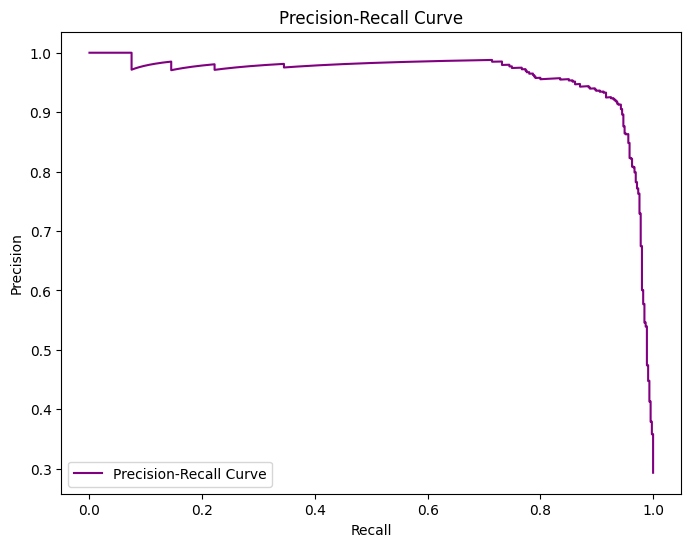

In [8]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
print(precision, recall)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color="purple", label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

### What is SVM (Support Vector Machine)?

**Support Vector Machine (SVM)** is a powerful, supervised machine learning algorithm primarily used for **classification** tasks, although it can also be used for **regression** (SVR — Support Vector Regression). SVM aims to find the optimal boundary (called a **hyperplane**) that best separates data points of different classes.

### Basic Working of SVM:

SVM works by finding a **hyperplane** that maximizes the margin between two classes. The **margin** is defined as the distance between the closest data points from each class to the hyperplane. These closest points are called **support vectors**.

In simple terms, SVM tries to draw a straight line (in 2D) or a hyperplane (in higher dimensions) that divides the data into two classes, and it aims to ensure that the gap between the two classes is as wide as possible. This helps in making better predictions on unseen data.

#### Key Concepts in SVM:
1. **Support Vectors**: These are the data points that are closest to the hyperplane and are crucial in defining the boundary. They "support" or define the hyperplane.
2. **Hyperplane**: The decision boundary that separates the different classes in the data. In a 2D space, this is just a line, but in higher-dimensional spaces, it's a plane or hyperplane.
3. **Margin**: The distance between the hyperplane and the nearest support vectors from each class. SVM aims to maximize this margin to improve the generalization of the model.

### How Does SVM Work for Classification?

1. **Linear Separation**: If the data is linearly separable (i.e., a straight line or hyperplane can perfectly separate the classes), SVM tries to find the hyperplane that maximizes the margin between the two classes.
2. **Non-linear Separation**: If the data cannot be separated linearly, SVM uses a technique called the **kernel trick**. This involves transforming the data into a higher-dimensional space where it becomes linearly separable. Some common kernels include:
   - **Linear kernel**: For linearly separable data.
   - **Polynomial kernel**: For more complex, but still separable, data.
   - **Radial Basis Function (RBF) kernel**: A popular kernel for non-linear problems, allowing the model to handle more complex relationships between classes.

### SVM for Regression (SVR):

SVM can also be used for **regression** problems, where the goal is to predict a continuous value. Instead of finding a hyperplane that separates two classes, SVR tries to find a hyperplane that best fits the data within a certain margin of tolerance, minimizing the prediction error.

### What is SVC (Support Vector Classification)?

**Support Vector Classification (SVC)** is simply the classification version of SVM. It's a specific implementation of the Support Vector Machine algorithm tailored to classification tasks.

In SVC:
- **SVC** finds the best hyperplane (or decision boundary) that divides the data into different classes.
- SVC aims to maximize the margin between classes, leading to better classification results on new, unseen data.

### Key Steps in SVC:
1. **Training the Model**: SVC is trained by providing labeled data (features and their corresponding classes). The model will try to find the optimal hyperplane that maximizes the margin between classes.
2. **Making Predictions**: Once the model is trained, it uses the learned hyperplane to classify new data points.
3. **Kernel Trick (if necessary)**: If the data is not linearly separable, SVC uses a kernel function to map the data into a higher-dimensional space where the classes can be separated linearly.

### Key Hyperparameters of SVC:
1. **`C`**: The **regularization parameter**. A higher value of `C` tries to fit the training data as accurately as possible, which can lead to overfitting. A smaller value of `C` allows more margin violations and can lead to better generalization.
2. **`kernel`**: The type of kernel to use (e.g., `linear`, `rbf`, `poly`, etc.). The kernel transforms the data into a higher-dimensional space for better separation.
3. **`gamma`**: A parameter used with certain kernels (like `rbf`) to define how far the influence of a single training example reaches. A low value makes the decision boundary smoother, and a high value makes the boundary more complex.
4. **`degree`**: Used for the polynomial kernel to specify the degree of the polynomial.

### Advantages of SVM:
1. **Effective in High Dimensional Spaces**: SVM works well for high-dimensional data, which is typical in fields like text classification or image recognition.
2. **Works Well with Clear Margin of Separation**: If the data is well-separated, SVM tends to provide excellent performance.
3. **Robust to Overfitting**: SVMs are less prone to overfitting, especially when using the appropriate regularization (`C` and `kernel` settings).

### Disadvantages of SVM:
1. **Computationally Intensive**: For very large datasets, SVM can be slow and require significant computational resources.
2. **Requires Tuning**: Choosing the correct **kernel**, **C**, and **gamma** values can be challenging, and the performance of SVM can be highly sensitive to these choices.
3. **Hard to Interpret**: The model’s decision boundary is not always easy to understand, especially in higher-dimensional spaces.